## Dimensionality Reduction on Text data.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE, MDS

In [8]:
df = pd.read_csv('datasets/bbc-text.csv')
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [9]:
df.shape

(2225, 2)

In [10]:
print("Categories:\n", df['category'].value_counts())

Categories:
 category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [11]:
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X = tfidf.fit_transform(df['text']) # sparse matrix (n_docs × 3000)
X_dense = X.toarray() # dense for PCA/LDA/t-SNE/MDS
le = LabelEncoder()
y = le.fit_transform(df['category'])
classes = le.classes_
print("\nTF-IDF matrix shape:", X_dense.shape)


TF-IDF matrix shape: (2225, 3000)


In [14]:
PALETTE = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261']
color_map = {i: PALETTE[i] for i in range(len(classes))}
point_colors = [color_map[i] for i in y]
handles = [patches.Patch(color=PALETTE[i], label=classes[i])
            for i in range(len(classes))]

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)
print("\n── PCA ──")
print(f"Explained Variance (PC1): {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Explained Variance (PC2): {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total Explained : {sum(pca.explained_variance_ratio_)*100:.1f}%")


── PCA ──
Explained Variance (PC1): 1.6%
Explained Variance (PC2): 1.3%
Total Explained : 2.9%


In [16]:
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_dense, y) # supervised — needs labels y
print("\n── LDA ──")
print(f"Explained Variance Ratio: {lda.explained_variance_ratio_}")


── LDA ──
Explained Variance Ratio: [0.67037221 0.14488422]


In [17]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X) # sparse X directly
print("\n── SVD (LSA) ──")
print(f"Explained Variance Ratio: {svd.explained_variance_ratio_}")
print(f"Total : {sum(svd.explained_variance_ratio_)*100:.1f}%")


── SVD (LSA) ──
Explained Variance Ratio: [0.00299178 0.01540284]
Total : 1.8%


In [18]:
N = 500 # subsample for speed
idx = np.random.choice(len(X_dense), N, replace=False)
mds = MDS(n_components=2, metric=True, random_state=42, n_jobs=-1)
X_mds = mds.fit_transform(X_dense[idx])
y_mds = y[idx]
pc_mds = [color_map[i] for i in y_mds]
print("\n── MDS ──")
print(f"Stress : {mds.stress_:.2f} (lower is better)")

c:\Users\shaji\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(



── MDS ──
Stress : 41842.02 (lower is better)


In [ ]:
X_pca50 = PCA(n_components=50, random_state=42).fit_transform(X_dense)
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            random_state=42, verbose=0)
X_tsne = tsne.fit_transform(X_pca50)
print("\n── t-SNE ──")
print("Note: t-SNE has no explained variance — non-linear method")


── t-SNE ──
Note: t-SNE has no explained variance — non-linear method


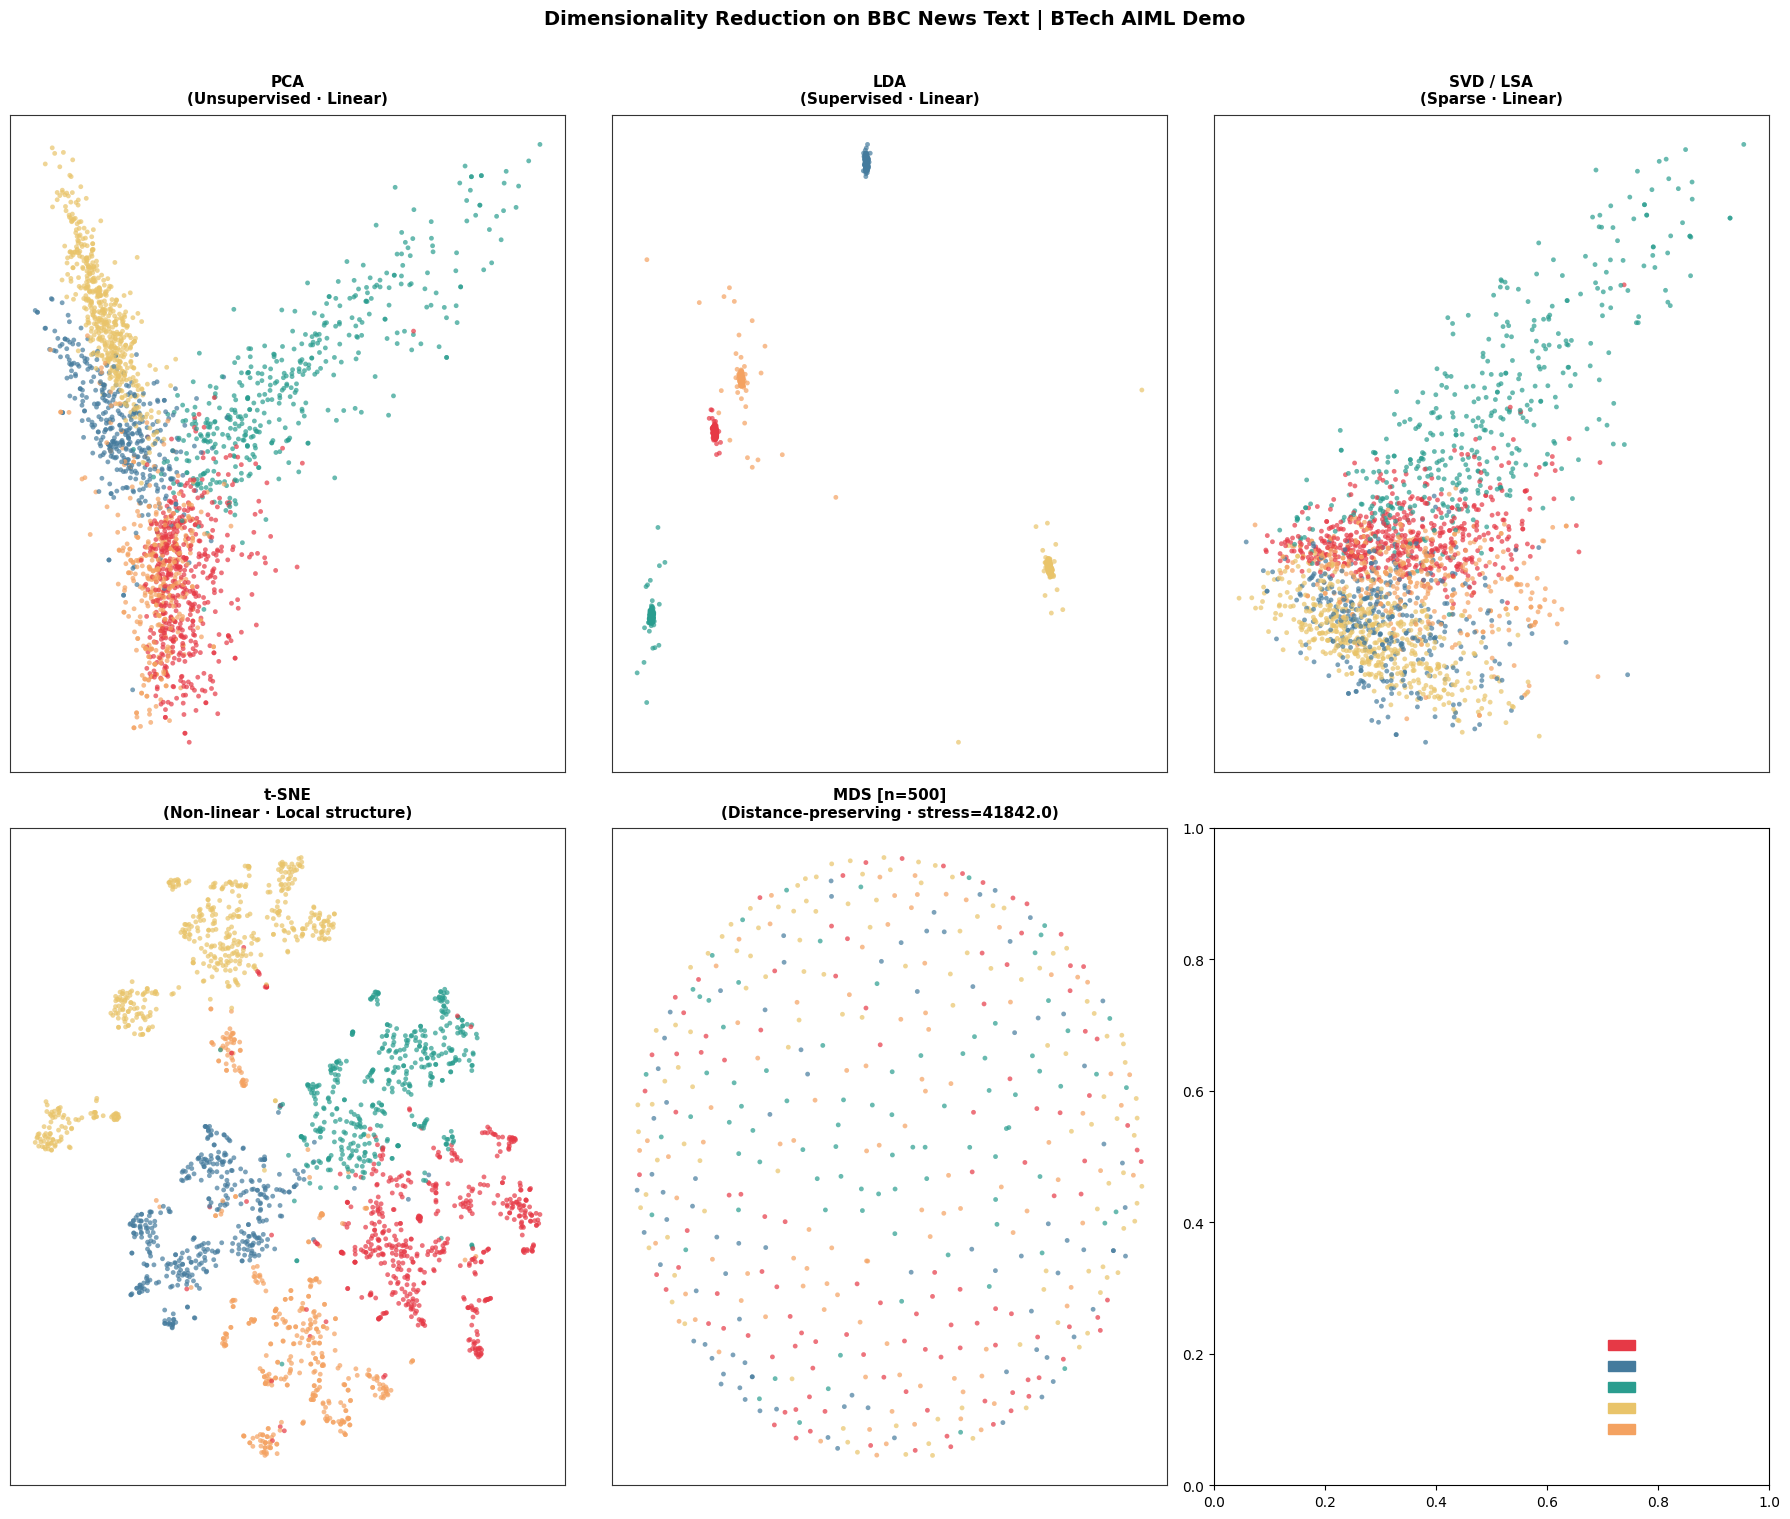

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 15))
axes_flat = axes.flatten()

plots = [
(X_pca, point_colors, "PCA\n(Unsupervised · Linear)"),
(X_lda, point_colors, "LDA\n(Supervised · Linear)"),
(X_svd, point_colors, "SVD / LSA\n(Sparse · Linear)"),
(X_tsne, point_colors, "t-SNE\n(Non-linear · Local structure)"),
(X_mds, pc_mds, f"MDS [n={N}]\n(Distance-preserving · stress={mds.stress_:.1f})"),
]

for ax, (coords, colors, title) in zip(axes_flat, plots):
    ax.scatter(coords[:, 0], coords[:, 1],

    c=colors, s=12, alpha=0.7, linewidths=0)

    ax.set_title(title,  fontsize=11, fontweight='bold', pad=8)
    ax.tick_params(colors='#555', labelleft=False, labelbottom=False,

    left=False, bottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

fig.legend(handles=handles, loc='lower right',
bbox_to_anchor=(0.98, 0.05), frameon=False,
fontsize=10, labelcolor='white', ncol=1)

fig.suptitle("Dimensionality Reduction on BBC News Text | BTech AIML Demo", fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()